Importação

In [34]:
#Importação
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import random as rd

# aplicacao
from sklearn.preprocessing import scale
from sklearn.covariance import EmpiricalCovariance, MinCovDet
from sklearn.model_selection import train_test_split

Pergunta 2

In [35]:
df1 = pd.read_csv('vendas_linha_petshop_2019.csv', sep=';', encoding='latin',decimal=',')
df2 = pd.read_csv('vendas_linha_petshop_2020.csv', sep=';', encoding='latin',decimal=',')
df3 = pd.read_csv('vendas_linha_petshop_2021.csv', sep=';', encoding='latin',decimal=',')
df4 = pd.read_csv('vendas_linha_petshop_2022.csv', sep=';', encoding='latin',decimal=',')
df = pd.concat([df1, df2, df3, df4], ignore_index=True)

<Axes: >

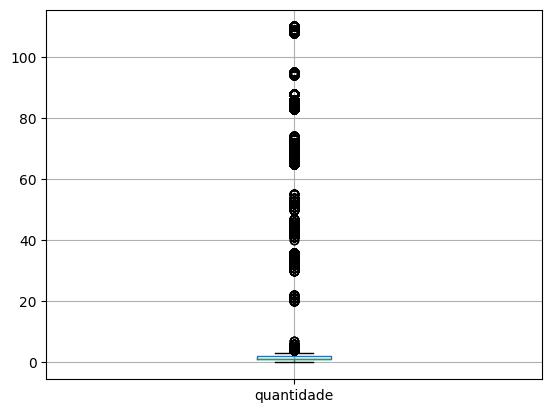

In [36]:
df['quantidade'] = pd.to_numeric(df['quantidade'], errors='coerce')
df[['quantidade']].boxplot()

In [37]:
def clean_col(col):
    return pd.to_numeric(df[col].astype(str).str.replace(',', '.'), errors='coerce')

df['quantidade'] = clean_col('quantidade')
df['valor_total_bruto'] = clean_col('valor_total_bruto')

# Remover nulos da coluna de análise
df_q = df.dropna(subset=['quantidade'])

# 3. Identificação de Outliers (Método IQR)
Q1 = df_q['quantidade'].quantile(0.25)
Q3 = df_q['quantidade'].quantile(0.75)
IQR = Q3 - Q1

limite_inferior = Q1 - 1.5 * IQR
limite_superior = Q3 + 1.5 * IQR

outliers = df_q[(df_q['quantidade'] < limite_inferior) | (df_q['quantidade'] > limite_superior)]
dados_normais = df_q[(df_q['quantidade'] >= limite_inferior) & (df_q['quantidade'] <= limite_superior)]

# 4. Cálculos e Justificativa
print(f"Limite Superior para Outliers: {limite_superior}")
print(f"Quantidade de Outliers encontrados: {len(outliers)}")

media_venda_outliers = outliers['valor_total_bruto'].mean()
media_venda_geral = df['valor_total_bruto'].mean()

print(f"Média de venda (Outliers de Qtd): R$ {media_venda_outliers:.2f}")
print(f"Média de venda (Geral): R$ {media_venda_geral:.2f}")


Limite Superior para Outliers: 3.5
Quantidade de Outliers encontrados: 11283
Média de venda (Outliers de Qtd): R$ 3949.74
Média de venda (Geral): R$ 420.97


Conclusão:

Total de vendas normais = 79.775.077,91
Total de vendas outliers = 44.564.916,42

As 11283 linhas que representam os outliers fizeram um pouco mais da metade do valor gerado pelas outras 189503 linhas não outliers.

In [38]:
#Estimativa de variabilidade
desvio_padrao_filtrado = dados_normais['quantidade'].std()
print(f"\nEstimativa de variabilidade (sem outliers): {desvio_padrao_filtrado:.2f}")


Estimativa de variabilidade (sem outliers): 0.78


Pergunta 3

In [39]:
df1 = pd.read_csv('vendas_linha_petshop_2019.csv', sep=';', encoding='latin',decimal=',')
df2 = pd.read_csv('vendas_linha_petshop_2020.csv', sep=';', encoding='latin',decimal=',')
df3 = pd.read_csv('vendas_linha_petshop_2021.csv', sep=';', encoding='latin',decimal=',')
df4 = pd.read_csv('vendas_linha_petshop_2022.csv', sep=';', encoding='latin',decimal=',')
df_completo = pd.concat([df1, df2, df3, df4], ignore_index=True)

In [40]:
# 2. Limpeza do campo 'valor' (ajustando vírgulas e convertendo para numérico)
def limpar_valor(col):
    return pd.to_numeric(col.astype(str).str.replace(',', '.').str.strip(), errors='coerce')

df_completo['valor'] = limpar_valor(df_completo['valor'])
df_completo = df_completo.dropna(subset=['valor'])



In [41]:
# 3. Cálculo da média da população
media_populacao = df_completo['valor'].mean()
print(f"Média da População: {media_populacao:.2f}\n")

# 4. Função para realizar o Teste T
def analisar_significancia(df, coluna_agrupadora, media_alvo):
    categorias = df[coluna_agrupadora].unique()
    resultados = []

    for cat in categorias:
        dados_cat = df[df[coluna_agrupadora] == cat]['valor']
        # Realiza o teste T de uma amostra
        t_stat, p_val = stats.ttest_1samp(dados_cat, media_alvo)

        resultados.append({
            'Categoria': cat,
            'Média': dados_cat.mean(),
            'P-valor': p_val,
            'Significativo (p < 0.05)': 'Sim' if p_val < 0.05 else 'Não'
        })

    return pd.DataFrame(resultados)

Média da População: 111.09



In [31]:
import scipy.stats as stats

# 5. Execução dos testes
res_regiao = analisar_significancia(df_completo, 'regiao_pais', media_populacao)
res_pagamento = analisar_significancia(df_completo, 'formapagto', media_populacao)

print("Comparação por Região:")
print(res_regiao)
print("\nComparação por Modalidade de Pagamento:")
print(res_pagamento)

Comparação por Região:
      Categoria       Média   P-valor Significativo (p < 0.05)
0         Norte  111.104489  0.986435                      Não
1  Centro Oeste  111.232447  0.904852                      Não
2      Nordeste  111.096483  0.993941                      Não
3       Sudeste  111.076545  0.990723                      Não
4           Sul  110.867752  0.873130                      Não

Comparação por Modalidade de Pagamento:
         Categoria       Média   P-valor Significativo (p < 0.05)
0         Dinheiro  111.478064  0.719148                      Não
1              Pix  111.230406  0.895239                      Não
2  Boleto Bancário  110.585834  0.636612                      Não
3   Cartão Crédito  112.508530  0.191087                      Não
4    Cartão Débito  109.630472  0.170567                      Não


Pergunta 4

In [32]:
df1 = pd.read_csv('vendas_linha_petshop_2019.csv', sep=';', encoding='latin',decimal=',')
df2 = pd.read_csv('vendas_linha_petshop_2020.csv', sep=';', encoding='latin',decimal=',')
df3 = pd.read_csv('vendas_linha_petshop_2021.csv', sep=';', encoding='latin',decimal=',')
df4 = pd.read_csv('vendas_linha_petshop_2022.csv', sep=';', encoding='latin',decimal=',')
df_all = pd.concat([df1, df2, df3, df4], ignore_index=True)

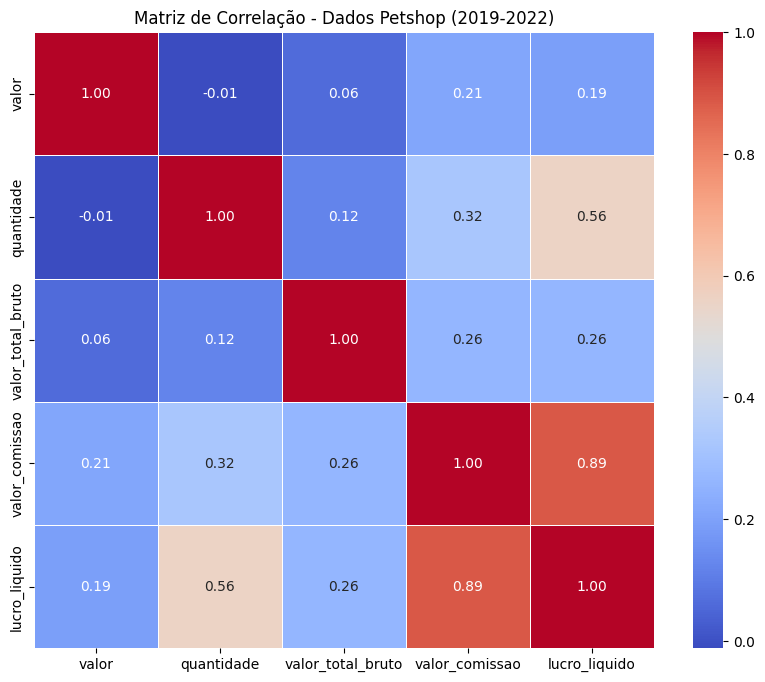

In [33]:
# Limpeza e conversão de dados numéricos (substituindo ',' por '.')
cols_to_convert = ['valor', 'quantidade', 'valor_total_bruto', 'valor_comissao', 'lucro_liquido']
for col in cols_to_convert:
    df_all[col] = pd.to_numeric(df_all[col].astype(str).str.replace(',', '.'), errors='coerce')

# Cálculo da matriz e geração do heatmap
corr_matrix = df_all[cols_to_convert].dropna().corr()
plt.figure(figsize=(10, 8))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5)
plt.title('Matriz de Correlação - Dados Petshop (2019-2022)')
plt.savefig('matriz_correlacao.png')

Valores com correlação positiva forte: valor_comissao e lucro-liquido

Valores com correlaçao negativa forte: quantidade e valor